**II. Programming and Critical Analysis**

**Part A: Clustering [5.5 v]**

Consider the diabetes.csv dataset (available on the course website), which aims to predict
whether a patient has diabetes based on various health-related attributes. Normalize data using
MinMaxScaler. Always use random_state = 42.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Select all variables, but outcome
df = pd.read_csv("diabetes.csv")
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

# Scale X variables with MinMax
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

1. Using sklearn, apply K-Means clustering on the normalized data with k = {2, 3, 4, 5, 6, 7, 8,
9, 10, 11}, max_iter = 500. Plot the SSE (sum of squared errors) values for each number of
clusters. [1.5 v]


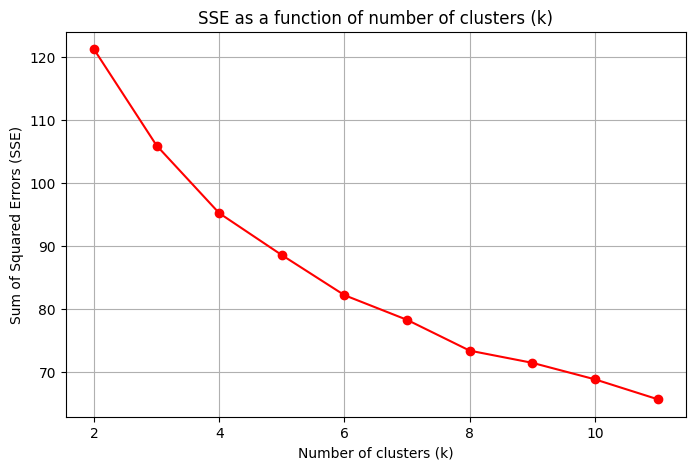

In [2]:
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
sse_values = []

for k in k_values:
  kmeans = KMeans(n_clusters=k, max_iter = 500, random_state=42)
  kmeans.fit(X_normalized)

  sse_values.append(kmeans.inertia_)

# Plot SSE as a function of k
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse_values, marker='o', linestyle='-', color='r')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('SSE as a function of number of clusters (k)')
plt.grid(True)
plt.show()

2. Using k=6, assign each observation to a cluster and classify them based on the majority
class of the cluster they belong to (Example: If cluster A has 100 observations of class 0
and 99 observations of class 1, classify all 199 observations as the majority class: 0 ).
Compute the confusion matrix, accuracy, precision, recall, and F1-score for this
classification model. Is this a good classification model? Justify your answer based on
your experience with classification models, and discuss the limitations of using clustering
for classification tasks. [2 v]

In [39]:
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_normalized) # model is trained for k=6

# Build a dataframe with outcome + cluster of each observation
normalized_df = pd.DataFrame(X_normalized, columns=X.columns, index=X.index)
normalized_df['Cluster'] = kmeans.labels_
normalized_df['Outcome'] = Y

# Take the most common outcome in each cluster
outcome_per_cluster = normalized_df.groupby('Cluster')['Outcome'].agg(lambda x: x.mode()[0])

# Assign the most common outcome in a cluster to all values in that cluster 
clustered_df = normalized_df
clustered_df['Outcome'] = clustered_df['Cluster'].map(outcome_per_cluster)

Y_pred = clustered_df['Outcome']

conf_matrix = confusion_matrix(Y, Y_pred)
acc = accuracy_score(Y, Y_pred)
prec = precision_score(Y, Y_pred)
rec = recall_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

Confusion Matrix:
 [[390 110]
 [119 149]]
Accuracy: 0.7018229166666666
Precision: 0.5752895752895753
Recall: 0.5559701492537313
F1-score: 0.5654648956356736


Este não é um bom modelo de classificação. Embora a accuracy seja 70%, as métricas críticas são fracas:

- Precision (57.5%) e Recall (55.6%) são insuficientes - o modelo falha em identificar corretamente 44% dos casos de diabetes (119      falsos negativos);
- No contexto médico, isto é crítico: pacientes diabéticos não diagnosticados não recebem tratamento.

Limitações do clustering para classificação:

- Não usa labels no treino - agrupa apenas por similaridade das features;
- Clusters heterogéneos - podem conter ambas as classes, gerando erros ao aplicar a regra da maioria;
- Performance inferior a modelos supervisionados (que tipicamente atingem >75% accuracy neste dataset).

Conclusão: Clustering é útil para exploração de dados, mas inadequado para classificação, especialmente em aplicações críticas. Métodos supervisionados (Logistic Regression, Random Forest) são muito mais apropriados.

3. Print the class distribution and the cluster centers for this model. Choose the 3 most
discriminative clusters and interpret the results. What can you conclude about the patients
in those clusters? [2 v]

In [3]:
# Train KMeans with k=6
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_normalized)

# Create dataframe with clusters and original outcome
result_df = pd.DataFrame(X_normalized, columns=X.columns)
result_df['Cluster'] = kmeans.labels_
result_df['Outcome'] = Y.values

# 1. Class distribution per cluster
print("="*60)
print("CLASS DISTRIBUTION PER CLUSTER:")
print("="*60)
class_dist = result_df.groupby('Cluster')['Outcome'].value_counts().unstack(fill_value=0)
class_dist.columns = ['No Diabetes', 'Diabetes']
class_dist['Total'] = class_dist.sum(axis=1)
class_dist['% Diabetes'] = (class_dist['Diabetes'] / class_dist['Total'] * 100).round(2)
print(class_dist)
print()

# 2. Cluster centers
print("="*60)
print("CLUSTER CENTERS (Normalized):")
print("="*60)
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
centroids_df.index.name = 'Cluster'
print(centroids_df.round(3))
print()

# 3. Identify most discriminative clusters
print("="*60)
print("MOST DISCRIMINATIVE CLUSTERS:")
print("="*60)
class_dist_sorted = class_dist.sort_values('% Diabetes', ascending=False)
print("Most discriminative = clusters with highest/lowest % Diabetes")
print(f"\nTop 3 by discrimination:")
print(f"- Cluster {class_dist_sorted.index[0]}: {class_dist_sorted['% Diabetes'].iloc[0]:.1f}% diabetes (high risk)")
print(f"- Cluster {class_dist_sorted.index[-1]}: {class_dist_sorted['% Diabetes'].iloc[-1]:.1f}% diabetes (low risk)")
print(f"- Cluster {class_dist_sorted.index[1]}: {class_dist_sorted['% Diabetes'].iloc[1]:.1f}% diabetes")

CLASS DISTRIBUTION PER CLUSTER:
         No Diabetes  Diabetes  Total  % Diabetes
Cluster                                          
0                 61        73    134       54.48
1                254        26    280        9.29
2                 43        26     69       37.68
3                 19        16     35       45.71
4                 74        51    125       40.80
5                 49        76    125       60.80

CLUSTER CENTERS (Normalized):
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
Cluster                                                                       
0              0.111    0.751          0.610          0.345    0.248  0.552   
1              0.104    0.498          0.549          0.239    0.069  0.447   
2              0.350    0.679          0.659          0.052    0.010  0.440   
3              0.213    0.592          0.000          0.015    0.000  0.383   
4              0.283    0.618          0.604          0.017    

Clusters mais discriminativos:
- Cluster 5 (60.8% diabetes): Pacientes de alto risco com elevado número de Pregnancies (0.502), Glucose alta (0.653), maior idade (0.381) e BMI elevado (0.511). Perfil característico de diabetes associada a múltiplas gestações e fatores metabólicos acumulados.

- Cluster 1 (9.3% diabetes): População muito saudável com Glucose moderada-baixa (0.498), BMI baixo (0.447), poucos Pregnancies (0.104) e idade jovem (0.070). Insulina muito baixa (0.069) indica boa resposta metabólica.

- Cluster 0 (54.5% diabetes): Perfil de risco metabólico elevado com Glucose muito alta (0.751), BloodPressure elevada (0.610) e BMI alto (0.552). Apesar da idade baixa (0.135), apresenta fatores de risco críticos para diabetes tipo 2.

Conclusão: Os clusters separam claramente perfis de risco. Glucose, Pregnancies, BMI e Age são as features mais discriminativas, identificando população saudável jovem vs. perfis de alto risco metabólico.

**Part B: PCA [5.5 v]**

Using the same dataset with the same normalization.

1. Apply Principal Component Analysis (PCA) and plot the cumulative explained variance by
the PCA components. How many principal components should be retained to explain at
least 80% of the total variance? [1.5 v]

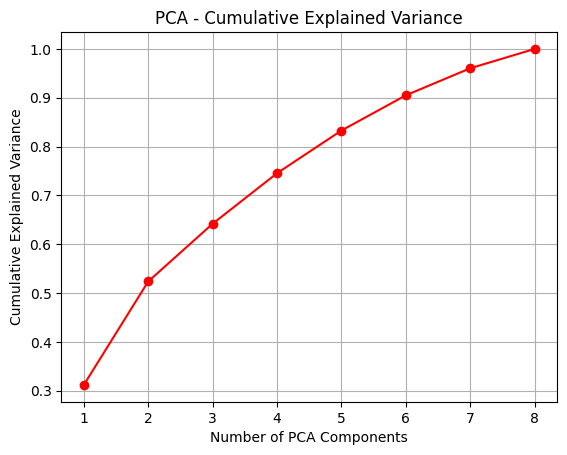

In [41]:
# Apply PCA to the normalized features
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_normalized)

# Compute cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='r')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

Para explicar pelo menos 80% da variância total, é necessário reter 5 componentes.

2. Plot the class distribution along the first principal component and comment. [1 v]


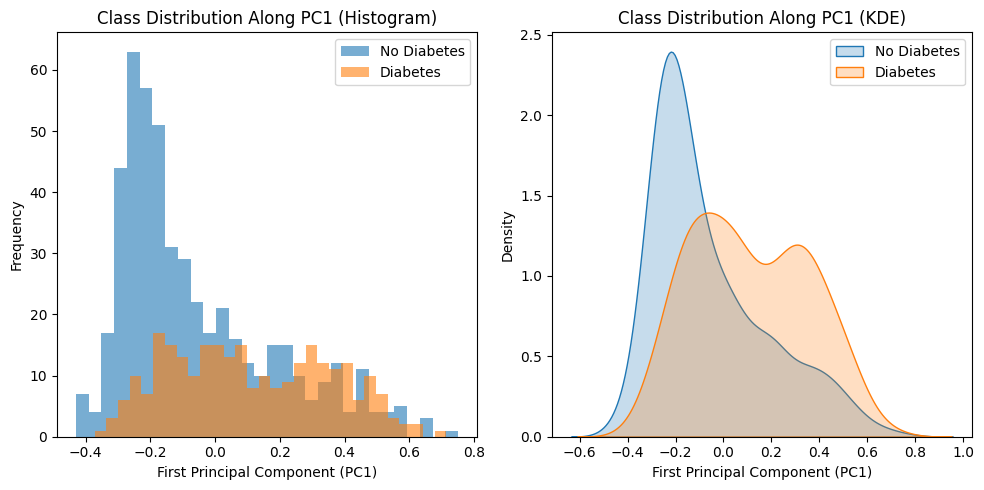

Variance explained by PC1: 0.3119 (31.19%)


In [5]:
# PCA with 1 component
pca = PCA(n_components=1, random_state=42)
pc1 = pca.fit_transform(X_normalized)

# Create dataframe
pc1_df = pd.DataFrame({
    'PC1': pc1.flatten(),
    'Outcome': Y.values
})

# Plot distribution
plt.figure(figsize=(10, 5))

# Option 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(pc1_df[pc1_df['Outcome'] == 0]['PC1'], alpha=0.6, label='No Diabetes', bins=30)
plt.hist(pc1_df[pc1_df['Outcome'] == 1]['PC1'], alpha=0.6, label='Diabetes', bins=30)
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Frequency')
plt.title('Class Distribution Along PC1 (Histogram)')
plt.legend()

# Option 2: KDE plot
plt.subplot(1, 2, 2)
sns.kdeplot(data=pc1_df[pc1_df['Outcome'] == 0]['PC1'], label='No Diabetes', fill=True)
sns.kdeplot(data=pc1_df[pc1_df['Outcome'] == 1]['PC1'], label='Diabetes', fill=True)
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Density')
plt.title('Class Distribution Along PC1 (KDE)')
plt.legend()

plt.tight_layout()
plt.show()

# Print explained variance
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")

PC1 explica apenas 31.19% da variância total e mostra sobreposição significativa entre as classes. A distribuição de pacientes diabéticos está mais dispersa e deslocada para valores positivos de PC1, enquanto não-diabéticos concentram-se em valores negativos. No entanto, a separação é fraca - há considerável overlap entre as classes.

Isto é esperado porque PCA é não-supervisionado: maximiza variância total dos dados, não a separabilidade entre classes. A primeira componente captura a direção de maior variação global, que não corresponde necessariamente à melhor discriminação entre diabéticos e não-diabéticos.

Conclusão: PC1 não é adequado para discriminar eficazmente as duas classes, evidenciando as limitações de métodos não-supervisionados para tarefas de classificação.

3. Apply Linear Discriminant Analysis (LDA) and plot the class distribution along the LDA
component. Comment on the results. [1.5 v]

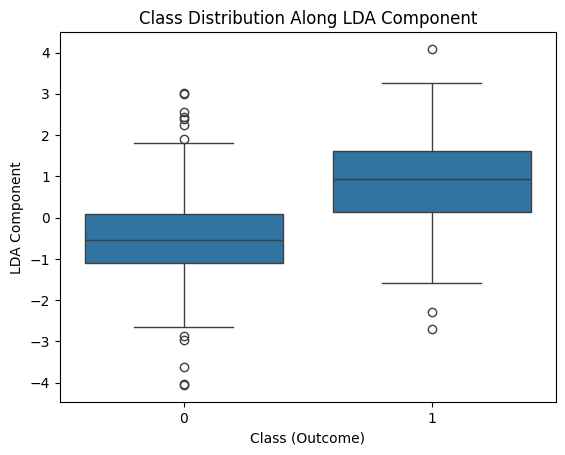

In [43]:
lda = LDA(n_components=1)  # for binary classification, only 1 component is possible
X_lda = lda.fit_transform(X_normalized, Y)

df_lda = pd.DataFrame({
    'LDA1': X_lda.flatten(),
    'Outcome': Y.values
})

plt.figure()
sns.boxplot(x='Outcome', y='LDA1', data=df_lda)
plt.title('Class Distribution Along LDA Component')
plt.xlabel('Class (Outcome)')
plt.ylabel('LDA Component')
plt.show()

O método LDA mostra uma separação nítida entre as classes ao longo da sua única componente: os não-diabéticos concentram-se em valores negativos (mediana ≈ -0,55) e os diabéticos em valores positivos (mediana ≈ 0,93), com as médias afastadas cerca de 1,4 desvios-padrão. Ainda assim, as distribuições sobrepõem-se de forma assinalável nas caudas: usando esta componente como regra de classificação (limiar no ponto médio das médias), obter-se-ia uma accuracy de apenas ~76,8%, ou seja, cerca de 23% de erro. Assim, embora a discriminação seja claramente superior à da PC1 — que mal separava as classes —, um único eixo linear não é suficiente para distinguir diabéticos de não-diabéticos de forma fiável, o que indica que as classes não são linearmente separáveis com estas variáveis. Esta vantagem face à PCA resulta de o LDA ser supervisionado: maximiza a razão entre a variância inter-classes e intra-classes, projetando os dados na direção que melhor discrimina as duas classes, enquanto a PCA, não-supervisionada, apenas maximiza a variância total, ignorando os rótulos.


4. Which of the two methods (PCA or LDA) would be more appropriate for building a
discriminant rule? Justify your answer based on the results obtained and explain why that
method is more suitable. [1.5 v]


LDA é claramente mais apropriado para construir uma regra discriminante, pois:

- LDA maximiza separabilidade entre classes (supervisionado), enquanto PCA apenas maximiza variância total (não-supervisionado);

- Separação visível: LDA mostra medianas bem distintas entre classes, o método PCA apresenta grande sobreposição;

- Objetivo alinhado: Para classificação, queremos discriminar classes, não apenas reduzir dimensionalidade.

Conclusão: LDA é o método adequado quando o objetivo é discriminação/classificação, reservando-se o PCA para exploração de dados ou de redução de dimensionalidade sem considerar classes.